<div style="text-align:center; page-break-after:always; padding-top:30px">
<img src="img/portada_unam.png" alt="Escudo de la UNAM" width="220">
<h2>Universidad Nacional Autónoma de México</h2>
<h3>Diplomado en Técnicas Estadísticas y Minería de Datos, 42-2026</h3>
<h3>Módulo II. Modelos Estadísticos</h3>
<br><br>
<h1>Proyecto integrador</h1>
<h2>¿Importa dónde se coloca la barrera? Análisis del experimento A/B del juego móvil <i>Cookie Cats</i></h2>
<br><br>
<p style="text-align:center"><b>Autor:</b> Yago Raul Huerta Orozco<br>yagoraulhuertaorozco@gmail.com</p>
<p style="text-align:center"><b>Fecha:</b> 2 de octubre de 2026</p>
</div>

<a id="indice"></a>
## Índice

- [1. Introducción](#intro)
- [2. Descripción de los datos](#datos)
- [3. Metodología](#metodo)
- [4. Resultados](#resultados)
  - [4.1 Análisis exploratorio](#eda)
  - [4.2 Estimación puntual e intervalos de confianza](#est)
  - [4.3 Pruebas de hipótesis](#pruebas)
  - [4.4 Robustez](#robustez)
- [5. Conclusiones](#conclusiones)
- [Anexos](#anexos)
- [Fuentes de información](#fuentes)

<a id="intro"></a>
## 1. Introducción

*Cookie Cats* es un juego móvil de tipo *puzzle* (conecta tres) desarrollado por Tactile Entertainment. A medida que los jugadores avanzan por los niveles se encuentran con **barreras** (*gates*): puntos en los que deben esperar un tiempo determinado o realizar una compra dentro de la aplicación para continuar. Las barreras cumplen dos funciones: generan ingresos y, sobre todo, obligan a una pausa que, en teoría, aumenta el disfrute del juego a largo plazo.

Surge entonces una decisión de diseño: **¿en qué nivel conviene colocar la primera barrera?** Para responderla se implementó un **experimento A/B** en el que, al instalar el juego, cada usuario fue asignado a una de dos versiones:

- `gate_30`: la primera barrera aparece en el nivel 30 (grupo de control, la versión original).
- `gate_40`: la primera barrera se mueve al nivel 40 (grupo de tratamiento).

**Problema de análisis.** Una barrera más tardía podría mantener a los usuarios más tiempo "enganchados" o, al contrario, retrasar la pausa que los mantiene interesados. Como la retención es la métrica que más correlaciona con el valor de vida de un jugador, el interés se centra en ella.

**Pregunta que se desea responder.**

> ¿Cambiar la primera barrera del nivel 30 al nivel 40 modifica de manera estadísticamente significativa la **retención** de los jugadores (a 1 y a 7 días) y/o la **cantidad de rondas jugadas**?

**Objetivos específicos:**

1. Describir el conjunto de datos y verificar su calidad y la correcta asignación de los usuarios a cada versión.
2. Explorar el comportamiento de los jugadores (rondas jugadas y retención) en cada versión.
3. Estimar de forma puntual y por intervalo las métricas de interés.
4. Contrastar formalmente, mediante pruebas de hipótesis, si existen diferencias entre versiones.
5. Interpretar los resultados, responder la pregunta y discutir las limitaciones del análisis.

<a id="datos"></a>
## 2. Descripción de los datos

Los datos provienen de Kaggle (*Mobile Games A/B Testing - Cookie Cats*, mursideyarkin, s. f.) y se encuentran en `Unidad_2/Data/cookie_cats.csv`. Cada fila corresponde a **un jugador** que instaló el juego durante la semana que duró el experimento. Las variables son:

| Variable | Tipo | Descripción |
|---|---|---|
| `userid` | entero | Identificador único del jugador. |
| `version` | categórica | Versión asignada: `gate_30` (control) o `gate_40` (tratamiento). |
| `sum_gamerounds` | entero | Número de rondas jugadas durante los primeros 14 días tras la instalación. |
| `retention_1` | lógica | `True` si el jugador volvió a jugar **1 día** después de instalar el juego. |
| `retention_7` | lógica | `True` si el jugador volvió a jugar **7 días** después de instalar el juego. |

Se cargan los módulos, se define un tema gráfico consistente y una función auxiliar `decision` que estandariza el reporte de cada prueba de hipótesis.

In [1]:
# Cargar módulos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "font.family": "sans-serif",
})

COLORES = {"gate_30": "#2a78d6", "gate_40": "#eb6834"}
ORDEN = ["gate_30", "gate_40"]
ALPHA = 0.05  # nivel de significancia usado en todo el cuaderno
RNG = np.random.default_rng(42)  # semilla fija para reproducibilidad del bootstrap


def decision(p_valor, alpha, h0_desc, h1_desc):
    # Reporta la decision de una prueba a partir del valor-p
    veredicto = "Rechazar H0" if p_valor <= alpha else "No rechazar H0"
    print(f"  H0       : {h0_desc}")
    print(f"  H1       : {h1_desc}")
    print(f"  valor-p  : {p_valor:.6f}  (alpha = {alpha})")
    print(f"  Decision : {veredicto}")
    return veredicto


# Cargar el conjunto de datos
df = pd.read_csv("../../Data/cookie_cats.csv")
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [2]:
# 2.1 Estructura, tipos, nulos y duplicados
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas\n")
df.info()
print(f"\nValores nulos en total      : {df.isna().sum().sum()}")
print(f"Filas completamente repetidas: {df.duplicated().sum()}")
print(f"userid repetidos             : {df['userid'].duplicated().sum()}")

Dimensiones: 90,189 filas x 5 columnas

<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          90189 non-null  int64
 1   version         90189 non-null  str  
 2   sum_gamerounds  90189 non-null  int64
 3   retention_1     90189 non-null  bool 
 4   retention_7     90189 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.2 MB

Valores nulos en total      : 0
Filas completamente repetidas: 0
userid repetidos             : 0


El conjunto contiene **90 189 jugadores** y 5 variables, **sin valores nulos ni registros duplicados**; cada `userid` aparece una sola vez, por lo que cada fila es un jugador distinto y se cumple el supuesto de independencia entre observaciones (al menos a nivel de identificador). Las variables de retención ya son lógicas, lo que permite calcular proporciones directamente con `mean()`.

In [3]:
# 2.2 Tamaño de cada grupo y verificacion de la asignacion (SRM)
conteo = df["version"].value_counts().reindex(ORDEN)
print(conteo.to_frame("n").assign(proporcion=lambda t: t["n"] / t["n"].sum()).round(4))

# Prueba chi-cuadrada de bondad de ajuste contra una asignacion 50/50
chi2, p_srm = stats.chisquare(conteo.values)
print(f"\nChi-cuadrada de bondad de ajuste (50/50): chi2 = {chi2:.3f}, valor-p = {p_srm:.4f}")

             n  proporcion
version                   
gate_30  44700      0.4956
gate_40  45489      0.5044

Chi-cuadrada de bondad de ajuste (50/50): chi2 = 6.902, valor-p = 0.0086


La asignación fue casi balanceada: 44 700 jugadores en `gate_30` (49.56 %) y 45 489 en `gate_40` (50.44 %). Sin embargo, la prueba chi-cuadrada de bondad de ajuste contra una asignación exacta 50/50 arroja un valor-p de 0.0086, es decir, la diferencia de tamaños es **estadísticamente distinguible** de lo esperado por azar. Se trata de un posible *sample ratio mismatch* (SRM). En términos prácticos la desviación es pequeñísima (0.44 puntos porcentuales) y no hay forma de saber con estos datos si fue un problema de aleatorización; se deja registrado como **limitación** (sección 5) y se continúa el análisis suponiendo que los grupos son comparables.

<a id="metodo"></a>
## 3. Metodología

**Unidad de análisis y diseño.** Cada jugador es una unidad experimental asignada a una de dos versiones; se comparan dos muestras independientes ($n_{30} = 44\,700$, $n_{40} = 45\,489$). Con tamaños de muestra tan grandes, los resultados asintóticos (teorema central del límite) son confiables.

**Métricas.**

| Métrica | Tipo | Parámetro de interés |
|---|---|---|
| `retention_1` | Bernoulli | $p$ = proporción que regresa a 1 día |
| `retention_7` | Bernoulli | $p$ = proporción que regresa a 7 días |
| `sum_gamerounds` | Cuantitativa discreta, muy asimétrica | $\mu$ (media) y mediana de rondas |

**Estimación puntual.** Se usan la proporción muestral $\hat p = x/n$ para la retención, y la media y mediana muestrales para las rondas.

**Intervalos de confianza (95 %).**

- Para cada proporción: intervalo de **Wilson**, que se comporta mejor que el de Wald cuando $\hat p$ se aleja de 0.5.
- Para la diferencia de proporciones $p_{30} - p_{40}$: intervalo de Wald, $\hat p_{30} - \hat p_{40} \pm z_{0.975}\sqrt{\hat p_{30}(1-\hat p_{30})/n_{30} + \hat p_{40}(1-\hat p_{40})/n_{40}}$.
- Para rondas, diferencia de medias y de medianas: **bootstrap percentil** (`scipy.stats.bootstrap`), porque la distribución es extremadamente asimétrica.

**Pruebas de hipótesis** (nivel de significancia $\alpha = 0.05$, bilaterales). Para cada métrica de retención $k \in \{1, 7\}$:

$$H_0: p_{30}^{(k)} = p_{40}^{(k)} \qquad \text{vs.} \qquad H_1: p_{30}^{(k)} \neq p_{40}^{(k)}$$

con la **prueba z de dos proporciones** (varianza combinada), contrastada con la prueba chi-cuadrada de independencia. Para las rondas:

$$H_0: \text{la distribución de rondas es la misma en ambas versiones} \qquad \text{vs.} \qquad H_1: \text{las distribuciones difieren}$$

con la prueba **U de Mann-Whitney**, adecuada para datos asimétricos y con valores extremos, y como contraste la **t de Welch** sobre las medias (sobre los datos completos y excluyendo el valor extremo).

**Tamaño del efecto y comparaciones múltiples.** Al probar tres métricas aumenta la probabilidad de un falso positivo, por lo que se reportan además los valores-p con corrección de **Bonferroni** ($\alpha/3$). Se calcula la *h* de Cohen para las proporciones, para distinguir significancia estadística de relevancia práctica.

**Herramientas.** Python 3.12 con `pandas`, `numpy`, `scipy.stats`, `matplotlib` y `seaborn`.

<a id="resultados"></a>
## 4. Resultados

<a id="eda"></a>
### 4.1 Análisis exploratorio

In [4]:
# 4.1.1 Resumen descriptivo de las rondas jugadas por version
resumen = df.groupby("version")["sum_gamerounds"].describe(percentiles=[.25, .5, .75, .95, .99]).reindex(ORDEN)
resumen["asimetria"] = df.groupby("version")["sum_gamerounds"].apply(stats.skew).reindex(ORDEN)
print(f"Jugadores que no jugaron ninguna ronda: {(df['sum_gamerounds'] == 0).sum():,} "
      f"({(df['sum_gamerounds'] == 0).mean():.2%})")
resumen.round(2)

Jugadores que no jugaron ninguna ronda: 3,994 (4.43%)


,count,mean,std,min,25%,50%,75%,95%,99%,max,asimetria
version,,,,,,,,,,,
gate_30,44700.0,52.46,256.72,0.0,5.0,17.0,50.0,222.0,493.00,49854.0,163.70
gate_40,45489.0,51.30,103.29,0.0,5.0,16.0,52.0,220.0,492.12,2640.0,5.97


La distribución de `sum_gamerounds` es **extremadamente asimétrica a la derecha**: la media (≈ 52 rondas) es unas tres veces mayor que la mediana (16-17 rondas), el 75 % de los jugadores juega alrededor de 50 rondas o menos y el máximo es de 49 854 rondas, una cifra implausible para 14 días de juego (probablemente un error de registro o un bot). Además, 3 994 jugadores (4.43 %) instalaron el juego pero **no jugaron ninguna ronda**. Estas características obligan a preferir estadísticos robustos (mediana, pruebas no paramétricas) y a revisar el efecto del valor extremo.

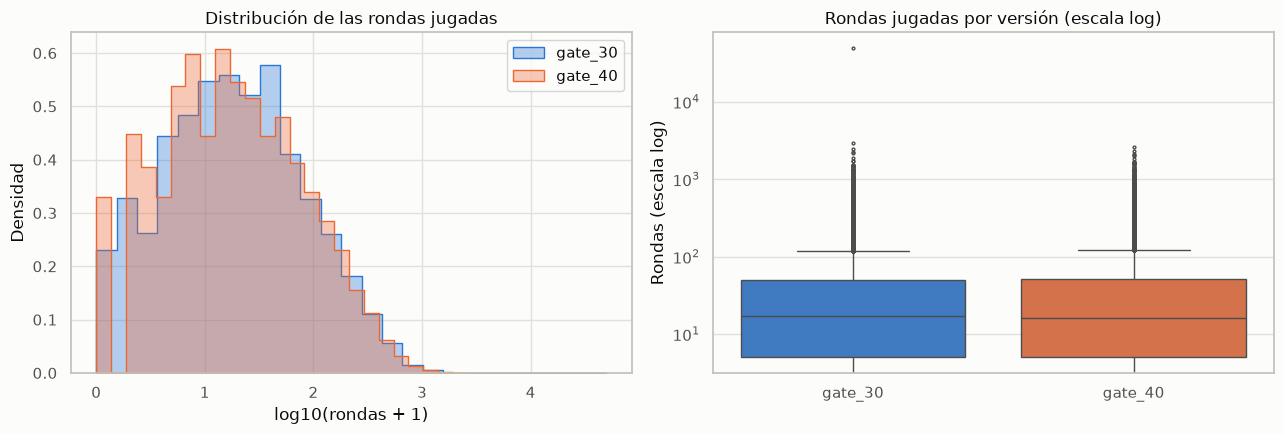

        userid  version  sum_gamerounds  retention_1  retention_7
57702  6390605  gate_30           49854        False         True
7912    871500  gate_30            2961         True         True
29417  3271615  gate_40            2640         True        False
43671  4832608  gate_30            2438         True         True
48188  5346171  gate_40            2294         True         True


In [5]:
# 4.1.2 Distribucion de las rondas jugadas (escala logaritmica) y valores extremos
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))

for v in ORDEN:
    sns.histplot(np.log10(df.loc[df["version"] == v, "sum_gamerounds"] + 1), bins=25, stat="density",
                 element="step", fill=True, alpha=.35, color=COLORES[v], label=v, ax=ejes[0])
ejes[0].set(title="Distribución de las rondas jugadas", xlabel="log10(rondas + 1)", ylabel="Densidad")
ejes[0].legend()

sns.boxplot(data=df, x="version", y="sum_gamerounds", order=ORDEN, palette=COLORES, hue="version",
            legend=False, ax=ejes[1], fliersize=2)
ejes[1].set(yscale="log", title="Rondas jugadas por versión (escala log)", xlabel="", ylabel="Rondas (escala log)")
plt.tight_layout()
plt.show()

print(df.nlargest(5, "sum_gamerounds")[["userid", "version", "sum_gamerounds", "retention_1", "retention_7"]])

En escala logarítmica las dos versiones tienen distribuciones prácticamente superpuestas, con una forma aproximadamente log-normal y un pico en valores bajos. Los diagramas de caja confirman que la mediana y los cuartiles son casi idénticos. Se observa un único valor claramente aislado: el jugador `6390605` (`gate_30`) con **49 854 rondas**, muy por encima del siguiente (2 961 rondas). Al ser un caso aislado y no poder confirmar que sea un error, se conserva en el análisis principal y se evalúa su influencia en la sección 4.4.

         retention_1 (%)  retention_7 (%)
version                                  
gate_30            44.82            19.02
gate_40            44.23            18.20


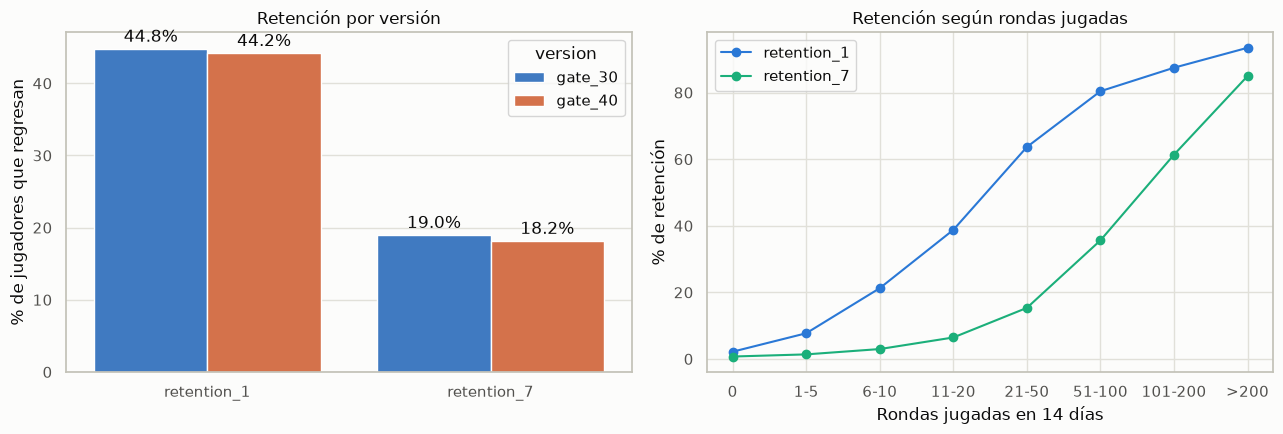

,retention_1,retention_7,n
sum_gamerounds,,,
0,2.2,0.7,3994
1-5,7.7,1.4,20723
6-10,21.3,3.0,11272
11-20,38.8,6.5,13813
21-50,63.7,15.3,17575
51-100,80.4,35.6,10427
101-200,87.5,61.4,7162
>200,93.5,85.0,5223


In [6]:
# 4.1.3 Retencion por version y relacion entre rondas jugadas y retencion
ret = df.groupby("version")[["retention_1", "retention_7"]].mean().reindex(ORDEN)
print((ret * 100).round(2).rename(columns=lambda c: c + " (%)"))

# Retencion segun tramos de rondas jugadas
tramos = pd.cut(df["sum_gamerounds"], [-1, 0, 5, 10, 20, 50, 100, 200, np.inf],
                labels=["0", "1-5", "6-10", "11-20", "21-50", "51-100", "101-200", ">200"])
por_tramo = df.groupby(tramos, observed=True)[["retention_1", "retention_7"]].mean() * 100
por_tramo["n"] = tramos.value_counts().reindex(por_tramo.index)

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))
ret_long = (ret * 100).reset_index().melt(id_vars="version", var_name="metrica", value_name="pct")
sns.barplot(data=ret_long, x="metrica", y="pct", hue="version", hue_order=ORDEN, palette=COLORES, ax=ejes[0])
ejes[0].set(title="Retención por versión", xlabel="", ylabel="% de jugadores que regresan")
for c in ejes[0].containers:
    ejes[0].bar_label(c, fmt="%.1f%%", padding=2)

por_tramo[["retention_1", "retention_7"]].plot(marker="o", ax=ejes[1], color=["#2a78d6", "#1baf7a"])
ejes[1].set(title="Retención según rondas jugadas", xlabel="Rondas jugadas en 14 días", ylabel="% de retención")
plt.tight_layout()
plt.show()
por_tramo.round(1)

La retención a 1 día ronda el 44-45 % y la de 7 días el 18-19 %, con **diferencias muy pequeñas entre versiones** (`gate_30` queda ligeramente por encima en ambas). La gráfica de la derecha muestra, además, una relación fuertemente creciente entre rondas jugadas y retención: quienes juegan 0 rondas casi nunca regresan, mientras que el 85 % de quienes juegan más de 200 rondas vuelve a los 7 días. Esto es esperable —quien se engancha juega más y regresa más— e implica que `sum_gamerounds` y la retención no son métricas independientes, lo que se retoma en las limitaciones.

<a id="est"></a>
### 4.2 Estimación puntual e intervalos de confianza

In [7]:
# 4.2.1 Proporciones de retencion: estimacion puntual e IC de Wilson al 95 %
filas = []
for metrica in ["retention_1", "retention_7"]:
    for v in ORDEN:
        x = df.loc[df["version"] == v, metrica]
        ic = stats.binomtest(int(x.sum()), len(x)).proportion_ci(confidence_level=0.95, method="wilson")
        filas.append({"metrica": metrica, "version": v, "n": len(x), "exitos": int(x.sum()),
                      "p_hat": x.mean(), "IC_inf": ic.low, "IC_sup": ic.high})
tabla_prop = pd.DataFrame(filas)
tabla_prop.round(4)

,metrica,version,n,exitos,p_hat,IC_inf,IC_sup
0,retention_1,gate_30,44700,20034,0.4482,0.4436,0.4528
1,retention_1,gate_40,45489,20119,0.4423,0.4377,0.4469
2,retention_7,gate_30,44700,8502,0.1902,0.1866,0.1939
3,retention_7,gate_40,45489,8279,0.1820,0.1785,0.1856


In [8]:
# 4.2.2 Diferencia de proporciones (gate_30 - gate_40): IC de Wald al 95 % y h de Cohen
def dif_proporciones(metrica, conf=0.95):
    a = df.loc[df["version"] == "gate_30", metrica]
    b = df.loc[df["version"] == "gate_40", metrica]
    p1, p2, n1, n2 = a.mean(), b.mean(), len(a), len(b)
    se = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
    z = stats.norm.ppf(1 - (1 - conf) / 2)
    h = 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))
    return {"metrica": metrica, "dif (30-40)": p1 - p2, "IC_inf": p1 - p2 - z * se,
            "IC_sup": p1 - p2 + z * se, "h_Cohen": h}

tabla_dif = pd.DataFrame([dif_proporciones(m) for m in ["retention_1", "retention_7"]])
tabla_dif.round(4)

,metrica,dif (30-40),IC_inf,IC_sup,h_Cohen
0,retention_1,0.0059,-0.0006,0.0124,0.0119
1,retention_7,0.0082,0.0031,0.0133,0.0211


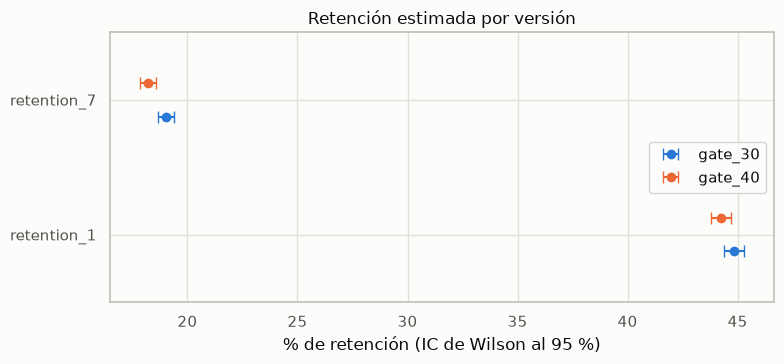

In [9]:
# 4.2.3 Grafica de las proporciones con sus intervalos de confianza
fig, ax = plt.subplots(figsize=(8, 3.8))
for i, m in enumerate(["retention_1", "retention_7"]):
    for j, v in enumerate(ORDEN):
        f = tabla_prop[(tabla_prop["metrica"] == m) & (tabla_prop["version"] == v)].iloc[0]
        y = i + (j - .5) * 0.25
        ax.errorbar(f["p_hat"] * 100, y, xerr=[[(f["p_hat"] - f["IC_inf"]) * 100], [(f["IC_sup"] - f["p_hat"]) * 100]],
                    fmt="o", color=COLORES[v], capsize=4, label=v if i == 0 else None)
ax.set_yticks([0, 1], ["retention_1", "retention_7"])
ax.set_ylim(-0.5, 1.5)
ax.legend(loc="center right")
ax.set(xlabel="% de retención (IC de Wilson al 95 %)", title="Retención estimada por versión")

plt.tight_layout()
plt.show()

**Estimación puntual.** La retención a 1 día es de **44.82 %** en `gate_30` y **44.23 %** en `gate_40`; la de 7 días es de **19.02 %** y **18.20 %**, respectivamente.

**Intervalos de confianza.** Los IC de Wilson al 95 % son estrechos (≈ ±0.45 pp en retención a 1 día y ≈ ±0.37 pp en la de 7 días) gracias al gran tamaño de muestra. Para la retención a **1 día** los intervalos de las dos versiones (44.36-45.28 % y 43.77-44.69 %) se traslapan mucho, y el IC para la diferencia es **[-0.06, 1.24] pp, que contiene al cero**. Para la retención a **7 días** los intervalos prácticamente se tocan (18.66-19.39 % vs. 17.85-18.56 %) y el IC de la diferencia es **[0.31, 1.33] pp, que no contiene al cero**: `gate_30` retiene entre 0.3 y 1.3 puntos porcentuales más. Las *h* de Cohen (0.012 y 0.021) son muy inferiores a 0.2, el umbral de un efecto "pequeño": las diferencias, aun siendo detectables, son de **magnitud muy reducida**.

In [10]:
# 4.2.4 Rondas jugadas: estimacion puntual e IC bootstrap (percentil, 95 %) de la diferencia
g30 = df.loc[df["version"] == "gate_30", "sum_gamerounds"].to_numpy()
g40 = df.loc[df["version"] == "gate_40", "sum_gamerounds"].to_numpy()

def boot_dif(estadistico, n_resamples):
    res = stats.bootstrap((g30, g40), lambda a, b, axis: estadistico(a, axis=axis) - estadistico(b, axis=axis),
                          n_resamples=n_resamples, confidence_level=0.95, method="percentile",
                          vectorized=True, random_state=RNG)
    return res.confidence_interval

ic_media = boot_dif(np.mean, 2000)
ic_mediana = boot_dif(np.median, 1000)

tabla_rondas = pd.DataFrame({
    "estadistico": ["media", "mediana"],
    "gate_30": [g30.mean(), np.median(g30)],
    "gate_40": [g40.mean(), np.median(g40)],
    "dif (30-40)": [g30.mean() - g40.mean(), np.median(g30) - np.median(g40)],
    "IC_inf": [ic_media.low, ic_mediana.low],
    "IC_sup": [ic_media.high, ic_mediana.high],
})
tabla_rondas.round(2)

,estadistico,gate_30,gate_40,dif (30-40),IC_inf,IC_sup
0,media,52.46,51.3,1.16,-0.98,3.97
1,mediana,17.00,16.0,1.00,0.00,1.00


La media de rondas es de 52.46 en `gate_30` y 51.30 en `gate_40` (diferencia de ≈ 1.16 rondas), y la mediana de 17 vs. 16 rondas. El IC bootstrap de la diferencia de medias, [−0.98, 3.97] rondas, incluye al cero con holgura, de modo que **no hay evidencia de una diferencia en la media de rondas jugadas**. Para la mediana el IC bootstrap es [0, 1] rondas: el cero queda justo en el extremo, y como la mediana de una variable discreta con valores tan bajos se mueve de uno en uno, una diferencia de a lo sumo 1 ronda es de escasa relevancia práctica.

<a id="pruebas"></a>
### 4.3 Pruebas de hipótesis

In [11]:
# 4.3.1 Prueba z de dos proporciones (retencion a 1 y 7 dias) + contraste chi-cuadrada
def prueba_z_proporciones(metrica):
    a = df.loc[df["version"] == "gate_30", metrica]
    b = df.loc[df["version"] == "gate_40", metrica]
    x1, n1, x2, n2 = a.sum(), len(a), b.sum(), len(b)
    p_comb = (x1 + x2) / (n1 + n2)
    z = (x1 / n1 - x2 / n2) / np.sqrt(p_comb * (1 - p_comb) * (1 / n1 + 1 / n2))
    p_z = 2 * stats.norm.sf(abs(z))
    chi2, p_chi, _, _ = stats.chi2_contingency(pd.crosstab(df["version"], df[metrica]), correction=False)
    return z, p_z, chi2, p_chi

resultados = {}
for metrica in ["retention_1", "retention_7"]:
    z, p_z, chi2, p_chi = prueba_z_proporciones(metrica)
    resultados[metrica] = p_z
    print(f"=== {metrica}: prueba z de dos proporciones ===")
    print(f"  z = {z:.4f}   |   chi-cuadrada = {chi2:.4f} (valor-p = {p_chi:.6f}; z^2 = {z**2:.4f})")
    decision(p_z, ALPHA, f"p_30 = p_40 en {metrica}", f"p_30 != p_40 en {metrica}")
    print()

=== retention_1: prueba z de dos proporciones ===
  z = 1.7841   |   chi-cuadrada = 3.1830 (valor-p = 0.074410; z^2 = 3.1830)
  H0       : p_30 = p_40 en retention_1
  H1       : p_30 != p_40 en retention_1
  valor-p  : 0.074410  (alpha = 0.05)
  Decision : No rechazar H0

=== retention_7: prueba z de dos proporciones ===
  z = 3.1644   |   chi-cuadrada = 10.0132 (valor-p = 0.001554; z^2 = 10.0132)
  H0       : p_30 = p_40 en retention_7
  H1       : p_30 != p_40 en retention_7
  valor-p  : 0.001554  (alpha = 0.05)
  Decision : Rechazar H0



In [12]:
# 4.3.2 Rondas jugadas: Mann-Whitney U (principal) y t de Welch (contraste)
u, p_u = stats.mannwhitneyu(g30, g40, alternative="two-sided")
t_all, p_t_all = stats.ttest_ind(g30, g40, equal_var=False)
resultados["sum_gamerounds"] = p_u

print("=== sum_gamerounds: Mann-Whitney U ===")
print(f"  U = {u:,.1f}")
decision(p_u, ALPHA, "misma distribucion de rondas en ambas versiones", "las distribuciones difieren")
print(f"\nContraste, t de Welch (datos completos): t = {t_all:.4f}, valor-p = {p_t_all:.4f}")

=== sum_gamerounds: Mann-Whitney U ===
  U = 1,024,331,250.5
  H0       : misma distribucion de rondas en ambas versiones
  H1       : las distribuciones difieren
  valor-p  : 0.050209  (alpha = 0.05)
  Decision : No rechazar H0

Contraste, t de Welch (datos completos): t = 0.8854, valor-p = 0.3759


In [13]:
# 4.3.3 Resumen con correccion de Bonferroni (3 pruebas)
resumen_pruebas = pd.DataFrame({"valor-p": resultados}).rename_axis("metrica")
resumen_pruebas["alpha"] = ALPHA
resumen_pruebas["rechaza H0 (sin corregir)"] = resumen_pruebas["valor-p"] <= ALPHA
resumen_pruebas["valor-p Bonferroni"] = (resumen_pruebas["valor-p"] * len(resumen_pruebas)).clip(upper=1)
resumen_pruebas["rechaza H0 (Bonferroni)"] = resumen_pruebas["valor-p Bonferroni"] <= ALPHA
resumen_pruebas.round(4)

,valor-p,alpha,rechaza H0 (sin corregir),valor-p Bonferroni,rechaza H0 (Bonferroni)
metrica,,,,,
retention_1,0.0744,0.05,False,0.2232,False
retention_7,0.0016,0.05,True,0.0047,True
sum_gamerounds,0.0502,0.05,False,0.1506,False


In [14]:
# 4.3.4 Potencia: diferencia minima detectable (80 % de potencia, alpha = 0.05, bilateral)
z_a, z_b = stats.norm.ppf(1 - ALPHA / 2), stats.norm.ppf(0.80)
n1, n2 = len(g30), len(g40)
for metrica in ["retention_1", "retention_7"]:
    p = df[metrica].mean()
    mde = (z_a + z_b) * np.sqrt(p * (1 - p) * (1 / n1 + 1 / n2))
    print(f"{metrica}: diferencia minima detectable ~ {mde * 100:.2f} puntos porcentuales")

retention_1: diferencia minima detectable ~ 0.93 puntos porcentuales
retention_7: diferencia minima detectable ~ 0.73 puntos porcentuales


**Retención a 1 día.** El estadístico es $z = 1.78$ con valor-p $= 0.0744 > 0.05$: **no se rechaza $H_0$**. Con los datos observados no se puede afirmar que la retención a 1 día difiera entre versiones; la diferencia de 0.59 pp es compatible con el azar. La chi-cuadrada coincide exactamente con $z^2$, como debe ser en una tabla 2×2.

**Retención a 7 días.** $z = 3.16$ con valor-p $= 0.0016 < 0.05$: **se rechaza $H_0$**. Existe evidencia estadística de que la retención a 7 días es mayor en `gate_30` (19.02 %) que en `gate_40` (18.20 %). La conclusión se mantiene tras la corrección de Bonferroni (valor-p ajustado ≈ 0.0047 < 0.05), por lo que no es un artefacto de probar varias métricas.

**Rondas jugadas.** La prueba de Mann-Whitney da un valor-p de 0.0502, **marginalmente por encima de $\alpha = 0.05$** (no se rechaza $H_0$), mientras que la t de Welch sobre las medias da valor-p = 0.376. El resultado de Mann-Whitney está en el límite, de modo que no conviene interpretarlo como evidencia clara en ningún sentido; en conjunto, **no hay evidencia sólida de que el número de rondas difiera entre versiones**.

**Potencia.** Con ~45 000 jugadores por grupo el experimento puede detectar diferencias de ≈ 0.9 pp en la retención a 1 día y ≈ 0.7 pp en la de 7 días con 80 % de potencia. La diferencia observada en la retención a 1 día (0.59 pp) queda por debajo de ese umbral, lo que explica por qué no resulta significativa; la de 7 días (0.82 pp) está por encima y sí se detecta.

<a id="robustez"></a>
### 4.4 Robustez

In [15]:
# 4.4.1 Efecto del valor extremo (49 854 rondas) y bootstrap de la diferencia de proporciones a 7 dias
g30_sin = g30[g30 < 10000]
t_sin, p_t_sin = stats.ttest_ind(g30_sin, g40, equal_var=False)
u_sin, p_u_sin = stats.mannwhitneyu(g30_sin, g40, alternative="two-sided")
print(f"Media gate_30 sin el valor extremo: {g30_sin.mean():.2f} (con el: {g30.mean():.2f})")
print(f"t de Welch sin extremo : t = {t_sin:.4f}, valor-p = {p_t_sin:.4f}")
print(f"Mann-Whitney sin extremo: valor-p = {p_u_sin:.4f}")

# Bootstrap de la diferencia de proporciones a 7 dias (remuestreo binomial)
a7 = df.loc[df["version"] == "gate_30", "retention_7"].mean()
b7 = df.loc[df["version"] == "gate_40", "retention_7"].mean()
dif_boot = RNG.binomial(n1, a7, 20000) / n1 - RNG.binomial(n2, b7, 20000) / n2
print(f"\nIC bootstrap 95 % de p30 - p40 (retention_7): [{np.percentile(dif_boot, 2.5) * 100:.2f}, "
      f"{np.percentile(dif_boot, 97.5) * 100:.2f}] pp")

Media gate_30 sin el valor extremo: 51.34 (con el: 52.46)
t de Welch sin extremo : t = 0.0634, valor-p = 0.9495
Mann-Whitney sin extremo: valor-p = 0.0509

IC bootstrap 95 % de p30 - p40 (retention_7): [0.31, 1.33] pp


Al excluir el único valor extremo, la media de `gate_30` baja de 52.46 a 51.34 rondas y es prácticamente igual a la de `gate_40` (51.30); la t de Welch pasa de valor-p = 0.376 a 0.949, y la conclusión de **no diferencia en rondas** se refuerza. El valor-p de Mann-Whitney apenas cambia porque es una prueba basada en rangos. El IC bootstrap para la diferencia en retención a 7 días es consistente con el de Wald y tampoco contiene al cero, de modo que el hallazgo principal es robusto al método de estimación.

<a id="conclusiones"></a>
## 5. Conclusiones

**Respuesta a la pregunta planteada.** Mover la primera barrera del nivel 30 al nivel 40 **no mejora ninguna de las métricas analizadas y, de hecho, parece empeorar ligeramente la retención a 7 días**:

| Métrica | gate_30 | gate_40 | Diferencia (30 − 40) | IC 95 % | Decisión (α = 0.05) |
|---|---|---|---|---|---|
| Retención a 1 día | 44.82 % | 44.23 % | 0.59 pp | [−0.06, 1.24] pp | No se rechaza H0 (p = 0.074) |
| Retención a 7 días | 19.02 % | 18.20 % | 0.82 pp | [0.31, 1.33] pp | **Se rechaza H0** (p = 0.0016) |
| Rondas jugadas (media) | 52.46 | 51.30 | 1.16 rondas | incluye 0 | No se rechaza H0 (Welch p = 0.376; Mann-Whitney p = 0.050) |

- La **retención a 7 días** es significativamente mayor con la barrera en el nivel 30, y el resultado resiste la corrección de Bonferroni y los métodos alternativos de estimación.
- La **retención a 1 día** y el **número de rondas** no muestran diferencias estadísticamente significativas.
- Aun cuando la diferencia a 7 días es estadísticamente significativa, su **magnitud es pequeña** (≈ 0.8 pp; *h* de Cohen ≈ 0.02). Para un juego con millones de instalaciones puede ser relevante; para uno con pocas, no.

**Recomendación.** Con la evidencia disponible **no se justifica mover la barrera al nivel 40**: no aporta mejoras detectables y la retención a 7 días tiende a ser menor. Conviene mantener la barrera en el nivel 30, salvo que otras métricas de negocio (ingresos, compras dentro de la aplicación) favorezcan claramente el cambio.

**Limitaciones del análisis.**

1. **Posible desbalance de la asignación (SRM).** Los grupos difieren de 50/50 de forma estadísticamente significativa (valor-p = 0.0086). La desviación es pequeña, pero podría indicar un problema en la aleatorización o en el registro, en cuyo caso los grupos podrían no ser perfectamente comparables.
2. **Falta de información sobre el diseño del experimento.** No hay fechas, plataforma, país ni otras covariables; no se puede verificar la aleatorización ni controlar por posibles variables de confusión, ni analizar efectos heterogéneos por tipo de jugador.
3. **Dependencia entre métricas.** Las rondas y la retención están fuertemente relacionadas (sección 4.1.3), y la retención a 7 días solo puede ocurrir en quienes siguieron jugando; las tres pruebas no son independientes, y la corrección de Bonferroni es conservadora.
4. **Valores extremos y calidad de datos.** Un caso con 49 854 rondas, y 4.4 % de jugadores con 0 rondas, sugieren posibles errores de registro o bots. Se conservaron los datos, pero su influencia se evaluó en la sección 4.4.
5. **Significancia vs. relevancia práctica.** Con muestras de ~45 000 por grupo, diferencias muy pequeñas pueden resultar significativas. El estudio no mide ingresos, por lo que no puede evaluar el efecto económico real de la barrera.
6. **Horizonte temporal acotado.** La retención se mide a 1 y 7 días y las rondas en 14 días; los efectos a largo plazo (30 días o más) no se observan.
7. **Supuestos de las pruebas.** Se supone independencia entre jugadores y validez de las aproximaciones asintóticas (razonable con estos tamaños de muestra); los valores-p de Mann-Whitney con muchos empates son aproximados.

<a id="anexos"></a>
## Anexos

### Anexo A. Cálculo manual de la prueba z de dos proporciones (retención a 7 días)

In [16]:
# Anexo A. Calculo paso a paso de la prueba z para retention_7
x1 = int(df.loc[df["version"] == "gate_30", "retention_7"].sum())
x2 = int(df.loc[df["version"] == "gate_40", "retention_7"].sum())
p1, p2, p_comb = x1 / n1, x2 / n2, (x1 + x2) / (n1 + n2)
ee = np.sqrt(p_comb * (1 - p_comb) * (1 / n1 + 1 / n2))
z_calc = (p1 - p2) / ee
print(f"x1 = {x1:,}, n1 = {n1:,}, p1 = {p1:.5f}")
print(f"x2 = {x2:,}, n2 = {n2:,}, p2 = {p2:.5f}")
print(f"p combinada = {p_comb:.5f};  error estandar = {ee:.6f}")
print(f"z = ({p1:.5f} - {p2:.5f}) / {ee:.6f} = {z_calc:.4f};  valor-p = {2 * stats.norm.sf(abs(z_calc)):.6f}")
print(f"Valor critico (alpha = 0.05, bilateral): +-{stats.norm.ppf(0.975):.3f}")

x1 = 8,502, n1 = 44,700, p1 = 0.19020
x2 = 8,279, n2 = 45,489, p2 = 0.18200
p combinada = 0.18606;  error estandar = 0.002592
z = (0.19020 - 0.18200) / 0.002592 = 3.1644;  valor-p = 0.001554
Valor critico (alpha = 0.05, bilateral): +-1.960


### Anexo B. Tablas completas de resultados

In [17]:
# Anexo B. Tablas de estimacion e intervalos
print("Proporciones de retencion con IC de Wilson al 95 %:")
display(tabla_prop.round(4))
print("Diferencia de proporciones (IC de Wald al 95 %) y h de Cohen:")
display(tabla_dif.round(4))
print("Rondas jugadas con IC bootstrap de la diferencia:")
display(tabla_rondas.round(2))
print("Resumen de pruebas de hipotesis:")
display(resumen_pruebas.round(4))

Proporciones de retencion con IC de Wilson al 95 %:


,metrica,version,n,exitos,p_hat,IC_inf,IC_sup
0,retention_1,gate_30,44700,20034,0.4482,0.4436,0.4528
1,retention_1,gate_40,45489,20119,0.4423,0.4377,0.4469
2,retention_7,gate_30,44700,8502,0.1902,0.1866,0.1939
3,retention_7,gate_40,45489,8279,0.1820,0.1785,0.1856


Diferencia de proporciones (IC de Wald al 95 %) y h de Cohen:


,metrica,dif (30-40),IC_inf,IC_sup,h_Cohen
0,retention_1,0.0059,-0.0006,0.0124,0.0119
1,retention_7,0.0082,0.0031,0.0133,0.0211


Rondas jugadas con IC bootstrap de la diferencia:


,estadistico,gate_30,gate_40,dif (30-40),IC_inf,IC_sup
0,media,52.46,51.3,1.16,-0.98,3.97
1,mediana,17.00,16.0,1.00,0.00,1.00


Resumen de pruebas de hipotesis:


,valor-p,alpha,rechaza H0 (sin corregir),valor-p Bonferroni,rechaza H0 (Bonferroni)
metrica,,,,,
retention_1,0.0744,0.05,False,0.2232,False
retention_7,0.0016,0.05,True,0.0047,True
sum_gamerounds,0.0502,0.05,False,0.1506,False


### Anexo C. Reproducibilidad

- Datos: `Unidad_2/Data/cookie_cats.csv` (sin modificaciones; no se eliminó ningún registro).
- Semilla del generador aleatorio para el bootstrap: `42`.
- Entorno: Python 3.12 con `pandas`, `numpy`, `scipy`, `matplotlib` y `seaborn` (ver `pyproject.toml` del repositorio).

<a id="fuentes"></a>
## Fuentes de información

Agresti, A., & Coull, B. A. (1998). Approximate is better than "exact" for interval estimation of binomial proportions. *The American Statistician, 52*(2), 119-126. https://doi.org/10.1080/00031305.1998.10480550

Cohen, J. (1988). *Statistical power analysis for the behavioral sciences* (2.ª ed.). Lawrence Erlbaum Associates.

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90-95. https://doi.org/10.1109/MCSE.2007.55

McKinney, W. (2010). Data structures for statistical computing in Python. En S. van der Walt & J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 56-61). https://doi.org/10.25080/Majora-92bf1922-00a

mursideyarkin. (s. f.). *Mobile games A/B testing - Cookie Cats* [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats

Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., … SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods, 17*(3), 261-272. https://doi.org/10.1038/s41592-019-0686-2

Waskom, M. L. (2021). seaborn: Statistical data visualization. *Journal of Open Source Software, 6*(60), 3021. https://doi.org/10.21105/joss.03021

Wilson, E. B. (1927). Probable inference, the law of succession, and statistical inference. *Journal of the American Statistical Association, 22*(158), 209-212. https://doi.org/10.1080/01621459.1927.10502953